# CLV Model Showdown: Probabilistic vs Machine Learning

**Question:** Which approach better predicts customer spending — a statistical model that
models buying/dying behavior (BG/NBD + Gamma-Gamma), or a machine learning model that
learns patterns directly from data (Gradient Boosting)?

**Setup:**
- Same dataset: 2,225 customers from marketing campaign data
- Same target: Total historical spending
- Same core features: Recency + Frequency
- Fair fight: identical test set for both models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

from lifetimes import BetaGeoFitter, GammaGammaFitter
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Load shared dataset
df = pd.read_csv('../data/preprocessed/david_clustered.csv')
print(f"Customers: {df.shape[0]}")
print(f"Avg Total Spending: ${df['Total_Spending'].mean():.0f}")
print(f"Avg Total Purchases: {df['Total_Purchases'].mean():.1f}")
df[['ID', 'Recency', 'Total_Purchases', 'Total_Spending', 'Cluster']].head()

Customers: 2225
Avg Total Spending: $607
Avg Total Purchases: 12.6


,ID,Recency,Total_Purchases,Total_Spending,Cluster
0,5524,58,22,1617,0
1,2174,38,4,27,1
2,4141,26,20,776,0
3,6182,26,6,53,2
4,5324,94,14,422,1


In [4]:
# === Derive BTYD metrics from the shared dataset ===
# The Lifetimes library needs specific RFM definitions:
#   Frequency: repeat purchases (total - 1, since first purchase doesn't count)
#   Recency: time between first and last purchase (Age - Recency_days_since_last)
#   T (Age): total observation period for each customer

# Use Dt_Customer to calculate customer age
last_date = pd.to_datetime('2014-10-04')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['T'] = (last_date - df['Dt_Customer']).dt.days  # customer age in days

# BTYD Frequency = repeat purchases only
df['btyd_frequency'] = df['Total_Purchases'] - 1

# BTYD Recency = age at last purchase = T - Recency (days since last purchase)
df['btyd_recency'] = df['T'] - df['Recency']

# Monetary value per transaction (for Gamma-Gamma model)
df['monetary_value'] = df['Total_Spending'] / df['Total_Purchases']

# Filter: Lifetimes requires frequency > 0
df_btyd = df[df['btyd_frequency'] > 0].copy()
print(f"Customers with repeat purchases: {len(df_btyd)} / {len(df)}")
print(f"\nBTYD metrics sample:")
df_btyd[['ID', 'btyd_frequency', 'btyd_recency', 'T', 'monetary_value', 'Total_Spending']].head()

Customers with repeat purchases: 2220 / 2225

BTYD metrics sample:


,ID,btyd_frequency,btyd_recency,T,monetary_value,Total_Spending
0,5524,21,702,760,73.500000,1617
1,2174,3,172,210,6.750000,27
2,4141,19,383,409,38.800000,776
3,6182,5,210,236,8.833333,53
4,5324,13,164,258,30.142857,422


In [5]:
# === Shared train/test split ===
# Both models get the EXACT same customers in train and test
# Using df_btyd (customers with repeat purchases) so Lifetimes model can run

train_idx, test_idx = train_test_split(
    df_btyd.index, test_size=0.2, random_state=42
)
df_train = df_btyd.loc[train_idx]
df_test = df_btyd.loc[test_idx]

print(f"Train: {len(df_train)} customers")
print(f"Test:  {len(df_test)} customers")
print(f"Target (Total_Spending) — Train mean: ${df_train['Total_Spending'].mean():.0f}, Test mean: ${df_test['Total_Spending'].mean():.0f}")

Train: 1776 customers
Test:  444 customers
Target (Total_Spending) — Train mean: $613, Test mean: $584


## Model A: BG/NBD + Gamma-Gamma (Probabilistic)

The "statistician's approach" — models two processes separately:
1. **BG/NBD** (retention): Will this customer buy again? How many times?
2. **Gamma-Gamma** (value): When they do buy, how much will they spend?

Predicted spend = predicted purchases × predicted avg transaction value

In [6]:
# === Model A: BG/NBD + Gamma-Gamma ===

# Step 1: Fit retention model (BG/NBD) on training data
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(df_train['btyd_frequency'], df_train['btyd_recency'], df_train['T'])
print("BG/NBD fitted:", bgf)

# Step 2: Fit value model (Gamma-Gamma) on training data
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(df_train['btyd_frequency'], df_train['monetary_value'])
print("Gamma-Gamma fitted:", ggf)

# Step 3: Predict on TEST set
# Predicted number of purchases over the observation period
pred_purchases = bgf.conditional_expected_number_of_purchases_up_to_time(
    df_test['T'],  # predict over each customer's full observation window
    df_test['btyd_frequency'],
    df_test['btyd_recency'],
    df_test['T']
)

# Predicted average transaction value
pred_avg_value = ggf.conditional_expected_average_profit(
    df_test['btyd_frequency'], df_test['monetary_value']
)

# Predicted total spend = purchases × avg value
df_test = df_test.copy()
df_test['pred_A'] = pred_purchases * pred_avg_value

print(f"\nModel A predictions on test set:")
print(f"  Avg predicted spend: ${df_test['pred_A'].mean():.0f}")
print(f"  Avg actual spend:    ${df_test['Total_Spending'].mean():.0f}")

BG/NBD fitted: <lifetimes.BetaGeoFitter: fitted with 1776 subjects, a: 0.04, alpha: 43.67, b: 3.27, r: 1.49>
Gamma-Gamma fitted: <lifetimes.GammaGammaFitter: fitted with 1776 subjects, p: 4.98, q: 1.48, v: 5.74>

Model A predictions on test set:
  Avg predicted spend: $482
  Avg actual spend:    $584


## Model B: Machine Learning Regression

The "engineer's approach" — learns the mapping from Recency + Frequency → Total Spending 
directly from the data. No assumptions about buying/dying processes. Just pattern matching.

We compare three ML models and crown the best one to face Model A.

In [7]:
# === Model B: ML Regression (3 models) ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

features = ['Recency', 'Total_Purchases']

X_train = df_train[features]
X_test = df_test[features]
y_train = df_train['Total_Spending']
y_test = df_test['Total_Spending']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features),
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print('=== ML MODELS ON TEST SET ===\n')
best_model_name = None
best_r2 = -np.inf

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    print(f'{name}:')
    print(f'  R²:  {r2:.3f}')
    print(f'  MAE: ${mae:.2f}')
    print()
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        df_test['pred_B'] = preds

print(f"Best ML model: {best_model_name} (R²={best_r2:.3f})")

=== ML MODELS ON TEST SET ===

Linear Regression:
  R²:  0.708
  MAE: $227.14

Random Forest:
  R²:  0.632
  MAE: $217.35

Gradient Boosting:
  R²:  0.712
  MAE: $205.57

Best ML model: Gradient Boosting (R²=0.712)


## Head-to-Head: Probabilistic vs Best ML Model

Same test set. Same target. Who wins?

In [8]:
# === Head-to-Head Metrics ===
actual = df_test['Total_Spending']

results = pd.DataFrame({
    'Model': ['A: BG/NBD + Gamma-Gamma', f'B: {best_model_name}'],
    'R²': [
        r2_score(actual, df_test['pred_A']),
        r2_score(actual, df_test['pred_B'])
    ],
    'MAE': [
        mean_absolute_error(actual, df_test['pred_A']),
        mean_absolute_error(actual, df_test['pred_B'])
    ],
    'RMSE': [
        root_mean_squared_error(actual, df_test['pred_A']),
        root_mean_squared_error(actual, df_test['pred_B'])
    ]
}).round(3)

print("=== HEAD-TO-HEAD COMPARISON ===\n")
print(results.to_string(index=False))

winner = results.loc[results['R²'].idxmax(), 'Model']
print(f"\nWinner by R²: {winner}")

=== HEAD-TO-HEAD COMPARISON ===

                  Model    R²     MAE    RMSE
A: BG/NBD + Gamma-Gamma 0.843 105.460 229.667
   B: Gradient Boosting 0.712 205.567 310.885

Winner by R²: A: BG/NBD + Gamma-Gamma


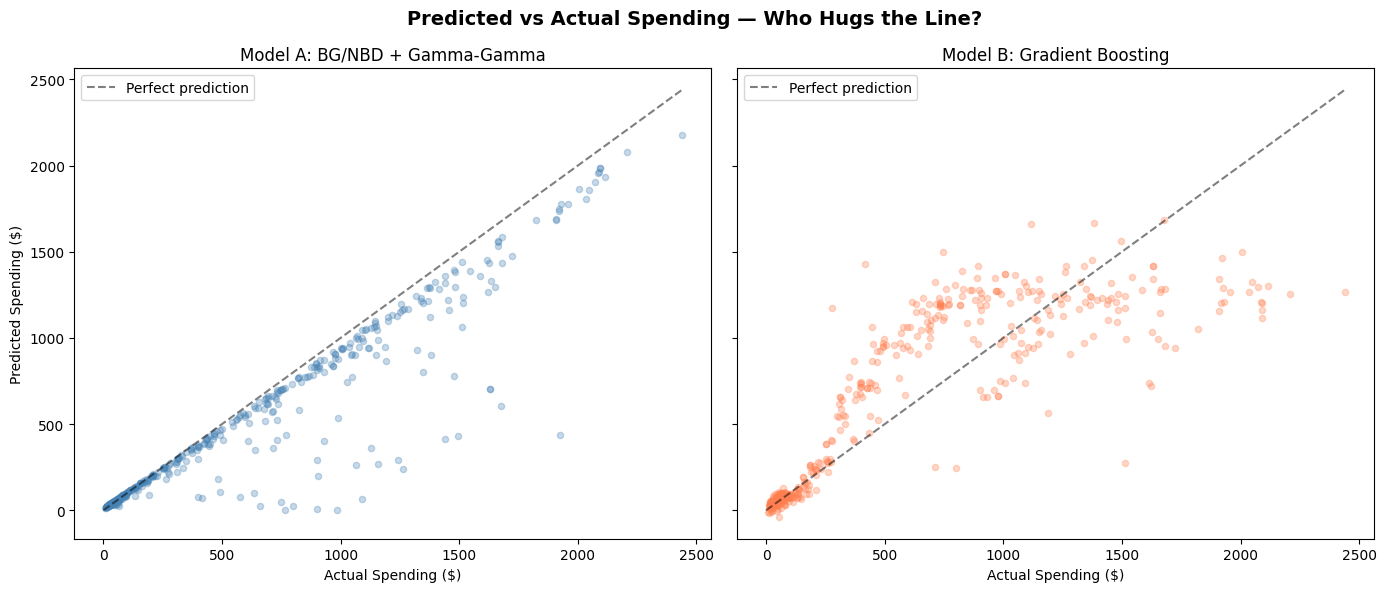

In [9]:
# === Predicted vs Actual — Both Models ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
max_val = max(actual.max(), df_test['pred_A'].max(), df_test['pred_B'].max())

# Model A
ax1.scatter(actual, df_test['pred_A'], alpha=0.3, c='steelblue', s=20)
ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')
ax1.set_xlabel('Actual Spending ($)')
ax1.set_ylabel('Predicted Spending ($)')
ax1.set_title('Model A: BG/NBD + Gamma-Gamma')
ax1.legend()

# Model B
ax2.scatter(actual, df_test['pred_B'], alpha=0.3, c='coral', s=20)
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')
ax2.set_xlabel('Actual Spending ($)')
ax2.set_title(f'Model B: {best_model_name}')
ax2.legend()

plt.suptitle('Predicted vs Actual Spending — Who Hugs the Line?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Where Each Model Wins

Breaking down error by customer cluster — probabilistic models often handle 
sparse/low-frequency customers better, while ML excels with data-rich segments.

In [10]:
# === Error Breakdown by Cluster ===
df_test['error_A'] = (df_test['pred_A'] - df_test['Total_Spending']).abs()
df_test['error_B'] = (df_test['pred_B'] - df_test['Total_Spending']).abs()
df_test['winner'] = np.where(df_test['error_A'] < df_test['error_B'], 'Probabilistic', 'ML')

# Summary by cluster
cluster_comparison = df_test.groupby('Cluster').agg(
    n_customers=('ID', 'count'),
    avg_spend=('Total_Spending', 'mean'),
    avg_purchases=('Total_Purchases', 'mean'),
    mae_probabilistic=('error_A', 'mean'),
    mae_ml=('error_B', 'mean'),
).round(1)

cluster_comparison['better_model'] = np.where(
    cluster_comparison['mae_probabilistic'] < cluster_comparison['mae_ml'],
    'Probabilistic', 'ML'
)

print("=== ERROR BY CLUSTER ===\n")
print(cluster_comparison.to_string())

# Overall customer-level wins
wins = df_test['winner'].value_counts()
print(f"\n=== CUSTOMER-LEVEL WINS ===")
print(f"Probabilistic closer: {wins.get('Probabilistic', 0)} customers")
print(f"ML closer:            {wins.get('ML', 0)} customers")

=== ERROR BY CLUSTER ===

         n_customers  avg_spend  avg_purchases  mae_probabilistic  mae_ml   better_model
Cluster                                                                                 
0                121     1159.6           18.0              249.4   323.9  Probabilistic
1                219      472.2           12.4               67.2   195.0  Probabilistic
2                104      151.9            7.0               18.5    90.1  Probabilistic

=== CUSTOMER-LEVEL WINS ===
Probabilistic closer: 360 customers
ML closer:            84 customers
